# EDA — VisDrone-DET2019

Detección de objetos desde perspectiva aérea  
Miguel Alejandro Flores Sotelo · Sergio de Jesús Castillo Molano

## Objetivo
Caracterizar el dataset VisDrone-DET2019 **antes de entrenar** cualquier modelo.
El EDA nos dirá exactamente qué estrategias de augmentación son necesarias.

## Contenido
1. Parseo de anotaciones → DataFrame
2. Distribución de clases
3. Distribución de tamaños de bounding boxes
4. Distribución de aspect ratio
5. Densidad de objetos por imagen
6. Distribución de resoluciones de imagen
7. Visualización de imágenes con bboxes
8. Análisis de truncación y oclusión

---

## 1. Parseo de anotaciones -> DataFrame

### Formato original de VisDrone
Cada archivo `.txt` tiene una línea por objeto detectado:
```
bbox_left, bbox_top, bbox_width, bbox_height, score, category, truncation, occlusion
```
- **score = 0** → región a ignorar (la filtramos)
- **category** → 0=ignorar, 1=pedestrian, ..., 10=motor (1-indexado; lo convertimos a 0-indexado)
- **truncation** → 0=completo, 1=parcialmente fuera del encuadre
- **occlusion** → 0=sin oclusión, 1=oclusión parcial, 2=oclusión pesada

In [11]:
#Imports
import yaml
import pandas as pd
from pathlib import Path

In [12]:
# Cargar configuración desde configs/visdrone.yaml
PROJECT_ROOT = Path("..")  # notebooks/ está un nivel abajo de la raiz (para llegar a la raiz del proyecto)
config_path  = PROJECT_ROOT / "configs" / "visdrone.yaml" #cosntruye la ruta al YAML

with open(config_path) as f:
    cfg = yaml.safe_load(f) #lee el yaml y lo convierte en un diccionario de python

DATASET_ROOT = PROJECT_ROOT / cfg["path"]
LABELS_TRAIN = DATASET_ROOT / cfg["labels"]["train"]
CLASS_NAMES  = cfg["names"]   # dict {0: 'pedestrian', 1: 'people', ...}

print(f"Raíz del dataset : {DATASET_ROOT.resolve()}") # .resolve() Obtiene la ruta completa y limpia desde la raíz del sistema.
print(f"Labels train     : {LABELS_TRAIN.resolve()}")
print(f"Clases           : {CLASS_NAMES}")

Raíz del dataset : /home/magicmike/TT-deteccion-aerea/data/visdrone
Labels train     : /home/magicmike/TT-deteccion-aerea/data/visdrone/labels/train
Clases           : {0: 'pedestrian', 1: 'people', 2: 'bicycle', 3: 'car', 4: 'van', 5: 'truck', 6: 'tricycle', 7: 'awning-tricycle', 8: 'bus', 9: 'motor'}


In [13]:
# Parsear todas las anotaciones del split train 
records = [] #lista de detecciones como diccionario
label_files = sorted(LABELS_TRAIN.glob("*.txt")) #busca todos los archivos .txt en dicha carpeta y se ordena alfabeticamente para que las detecciones s eporcesen en mismo orden (reproducibilidad)

for txt_file in label_files: #recorremos cada archivo de labels
    img_name = txt_file.stem  # nombre de archivo sin extensión (.txt)
    with open(txt_file) as f:
        for line in f: #abre el archivo y recorremos cada linea
            parts = line.strip().split(",") #quitamos espascioes en blanco , saltos de linea y lo dividimos por ,
            if len(parts) != 8: # filtro de seguirdad, cada deteccion debe tener 8 valores sino (esta corrupta)
                continue
            x, y, w, h, score, cat_id, trunc, occl = [int(p) for p in parts] #convertimos de string a int y le asignamos su variable

            # Filtrar regiones ignoradas (score=0) y categoría inválida (cat_id=0)
            if score == 0 or cat_id == 0:
                continue

            # VisDrone usa category 1-indexed -> convierte a 0-indexed
            cat_id_0 = cat_id - 1

            records.append({
                "image"       : img_name,
                "x"           : x,
                "y"           : y,
                "w"           : w,
                "h"           : h,
                "area"        : w * h, #numero d epixeles que ocupa el bounding box
                "aspect_ratio": round(w / h, 3) if h > 0 else 0, #que tan ancho es el objeto en relacion a su altura
                "cat_id"      : cat_id_0,
                "class"       : CLASS_NAMES[cat_id_0],
                "truncation"  : trunc,
                "occlusion"   : occl,
            })

df = pd.DataFrame(records) #convertimos la lista de diccionarios en un dataframe

print(f"Total de detecciones válidas (train) : {len(df):,}") #total de detecciones 
print(f"Imágenes únicas                      : {df['image'].nunique():,}") #total de imagene sunicas
print(f"Clases presentes                     : {df['class'].nunique()}") #total de clases unicas
print()
df.head(10)

Total de detecciones válidas (train) : 343,171
Imágenes únicas                      : 6,470
Clases presentes                     : 10



,image,x,y,w,h,area,aspect_ratio,cat_id,class,truncation,occlusion
0,0000002_00005_d_0000014,708,471,74,33,2442,2.242,3,car,0,1
1,0000002_00005_d_0000014,639,425,61,46,2806,1.326,3,car,0,0
2,0000002_00005_d_0000014,594,399,64,51,3264,1.255,3,car,0,0
3,0000002_00005_d_0000014,562,390,61,38,2318,1.605,3,car,0,0
4,0000002_00005_d_0000014,540,372,65,33,2145,1.970,3,car,0,1
5,0000002_00005_d_0000014,514,333,68,35,2380,1.943,3,car,0,0
6,0000002_00005_d_0000014,501,317,64,31,1984,2.065,3,car,0,1
7,0000002_00005_d_0000014,501,299,45,28,1260,1.607,3,car,0,1
8,0000002_00005_d_0000014,489,284,48,27,1296,1.778,3,car,0,1
9,0000002_00005_d_0000014,463,262,48,29,1392,1.655,3,car,0,0


## 2. Distribución de clases

Contamos cuántas detecciones hay de cada clase para confirmar el **desbalance severo**. Este análisis justifica las estrategias de augmentación dirigidas a clases minoritarias (copy-paste, class weighting, mosaic).

### Métricas a calcular
- Número total de detecciones por clase
- Porcentaje de cada clase respecto al total
- Clase mayoritaria y minoritaria
- **Ratio de desbalance** = mayoritaria / minoritaria (un valor > 10x se considera severo)

In [14]:
#Conteo de detecciones por clase
import matplotlib.pyplot as plt

#Contar detecciones por clase
class_counts=df["class"].value_counts()

#Calcular porcentajes
class_pct=(class_counts/len(df)*100).round(2)

#Tabla de resumen
class_summary=pd.DataFrame({
    "detecciones":class_counts,
    "porcentajes":class_pct
})

#Calcular ratio de desbalance
ratio=class_counts.max()/class_counts.min()

print(f"Total de detecciones: {len(df):,}")
print(f"Clase mayoritaria: {class_counts.idxmax()} ({class_counts.max():,})")
print(f"Clase minoritaria: {class_counts.idxmin()} ({class_counts.min():,})")
print(f"Ratio de desbalance: {ratio:.1f}x")
print()
class_summary


Total de detecciones: 343,171
Clase mayoritaria: car (144,865)
Clase minoritaria: awning-tricycle (3,243)
Ratio de desbalance: 44.7x



,detecciones,porcentajes
class,,
car,144865,42.21
pedestrian,79335,23.12
motor,29642,8.64
people,27059,7.88
van,24950,7.27
truck,12871,3.75
bicycle,10477,3.05
bus,5926,1.73
tricycle,4803,1.40


### Visualización
Gráfica de barras ordenada de mayor a menor para identificar visualmente qué clases dominan y cuáles son minoritarias.

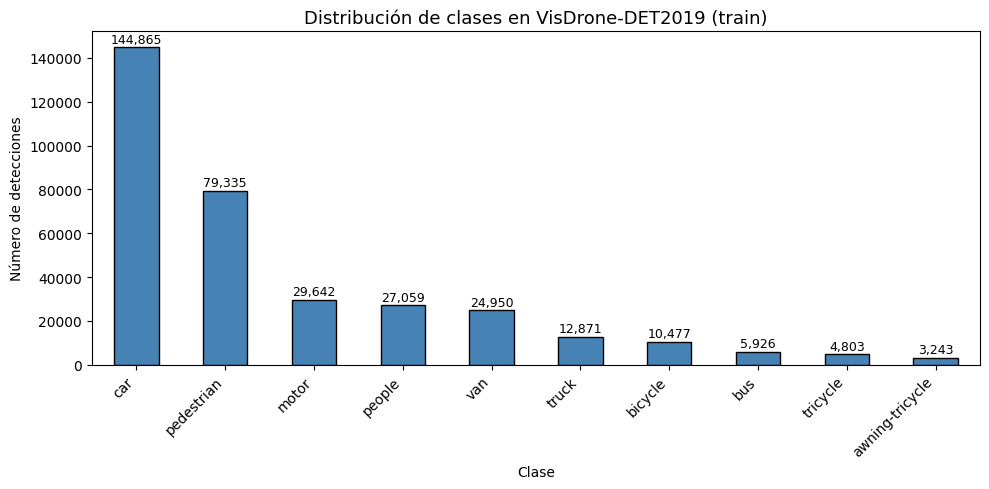

In [15]:
#Gráfica de barras: distribución de clases
fig,ax=plt.subplots(figsize=(10,5))

class_counts.plot(kind="bar",ax=ax, color="steelblue",edgecolor="black")

ax.set_title("Distribución de clases en VisDrone-DET2019 (train)", fontsize=13)
ax.set_xlabel("Clase")
ax.set_ylabel("Número de detecciones")
ax.set_xticklabels(class_counts.index,rotation=45,ha="right")

#Se agrga el valor encima de cada barra
for i,v in enumerate(class_counts.values):
    ax.text(i,v+2000,f"{v:,}",ha="center",fontsize=9)

plt.tight_layout()

#Guardamos la figura
output_dir = PROJECT_ROOT /"results" /"figures" /"eda"
output_dir.mkdir(parents=True,exist_ok=True)
plt.savefig(output_dir/"01_distribucion_clases.png",dpi=150,bbox_inches="tight")

#Guardamos la tabla
tables_dir = PROJECT_ROOT / "results" / "tables" / "eda"
tables_dir.mkdir(parents=True, exist_ok=True)
class_summary.to_csv(tables_dir / "01_distribucion_clases.csv")

plt.show()

## 3. Distribución de tamaños de bounding boxes

Caracterizamos el tamaño de los objetos para confirmar la predominancia de **small objects**, uno de los retos centrales del dominio aéreo.

### Criterio COCO (estándar internacional)
- **Small**  : área < 32² px (1,024 px²)
- **Medium** : 32² ≤ área < 96² px (1,024 a 9,216 px²)
- **Large**  : área ≥ 96² px (9,216 px²)

### Métricas a calcular
- Estadísticas descriptivas (media, mediana, percentiles) del área
- Porcentaje de objetos en cada categoría COCO
- Distribución del área por clase

In [ ]:
#Estadisticas descriptivas del área de los bbboxes

print("Estadísticas del área (px^2): ")
print(df["area"].describe().round(2))
print()
print(f"Área mínima:{df['area'].min():,}px^2")
print(f"Área máxima:{df['area'].max():,}px^2")
print(f"Mediana:{df['area'].median():,.0f}px^2")
print(f"Media:{df['area'].mean():,.0f}px^2")

Estadísticas del área (px^2): 
count    343171.00
mean       2447.99
std        6598.22
min           0.00
25%         243.00
50%         680.00
75%        2025.00
max      328640.00
Name: area, dtype: float64

Área mínima:0px^2
Área máxima:328,640px^2
Mediana:680px^2
Media:2,448px^2
